<a href="https://colab.research.google.com/github/ambroise-lb/Hand-Made-Neural-Net/blob/main/HM_DishBrain.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist

(X_train, y_train), (X_test, y_test) = mnist.load_data()

print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)


In [20]:
brain = np.random.choice([-1, 1], size=40)
brainTest = brain.copy()
brain2 = brain.copy()

W = np.random.choice([-1, 0, 1], size=((40, 40)), p=[0.2, 0.6, 0.2])
W = np.triu(W, k=1)
W = W + W.T

T = 0.1
T2 = 10

def Es(brain,W):
  E = -0.5 * (brain @ W @ brain)
  return(E)

def Epr(brain, W, i):
    somme_voisins = W[i, :] @ brain
    dE = -2 * brain[i] * somme_voisins
    return dE

def Psi(Ei, T):
    ei = np.exp(-(Ei/T))
    g = 1/(1+ei)
    return g

def update_T(succes):
    if succes:
        T = 0.1
    else:
        T = 10
    return T

StockEs = []
StockEs2 = []

[ 0  0  0 -2  0  0  0  0  2  0  0 -2  2  2  0  0  0  0  0  2  0  0  2  0
  2  0 -2  2  0  0  2  0  0 -2  2  0 -2  0  2  0]


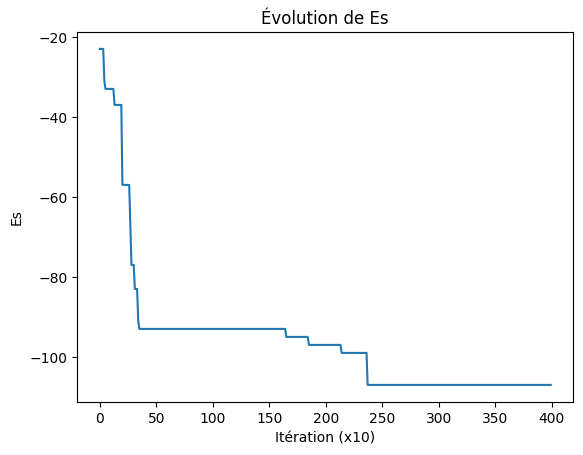

In [21]:
for cycle in range(10):
 for i in range(len(brain)):
  Energie = Es(brain, W)
  StockEs.append(Energie)
  Ei = Epr(brain, W, i)
  pi = Psi(Ei, T)
  tirage = np.random.rand()
  if tirage < pi:
    brain[i] *= -1


a = brain - brainTest
print(a)

plt.plot(StockEs)
plt.xlabel("Itération (x10)")
plt.ylabel("Es")
plt.title("Évolution de Es")
plt.show()

[ 0 -2  2  0  0  0  0  0  0  2  0 -2  2  2 -2  2  0  0  0  0  0  0  2  0
  2  0 -2  2  0  0  0  2  0  0  2  0 -2  0  0 -2]


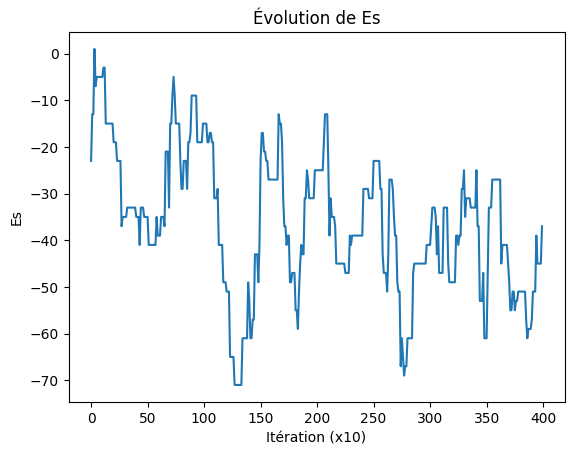

In [22]:
for cycle in range(10):
 for i in range(len(brain2)):
  Energie = Es(brain2, W)
  StockEs2.append(Energie)
  Ei = Epr(brain2, W, i)
  pi = Psi(Ei, T2)
  tirage = np.random.rand()
  if tirage < pi:
    brain2[i] *= -1


a = brain2 - brainTest
print(a)

plt.plot(StockEs2)
plt.xlabel("Itération (x10)")
plt.ylabel("Es")
plt.title("Évolution de Es")
plt.show()